## Test preprocessing

Ce notebook teste l'intégrité des données générée par le processus de preprocess

In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.dataset import IndexedDataset

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
dataset_train = IndexedDataset.create(config, DatasetType.TRAIN)
dataset_test = IndexedDataset.create(config, DatasetType.TEST)
dataset_validation = IndexedDataset.create(config, DatasetType.VALIDATION)

In [5]:
# validation quantite de labels
assert len(dataset_train.species_label) == 5
assert len(dataset_test.species_label) == 5
assert len(dataset_validation.species_label) == 5

In [6]:
# inspection visuelle
print(dataset_train.species_label)
print(len(dataset_train.species_label))

['Barn Swallow', 'Common Buzzard', 'Western Yellow Wagtail', 'Thrush Nightingale', 'Willow Warbler']
5


In [7]:
groupe_length, segment_length_, hop_length = config.preprocess.group_frame_infos()
print(groupe_length, segment_length_, hop_length)

60 30 15


In [8]:
# train
print(dataset_train.spectrogram_groups.shape)
print(dataset_train.y.shape)
print(dataset_train.y[:5])

num_samples, group_segment_count, n_mels, segment_length = dataset_train.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_train_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_train.lat_long.shape == (num_samples, 2)

np.unique( dataset_train.y )

(4116, 3, 128, 30)
(4116, 5)
[[0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]]


array([0, 1], dtype=int16)

In [9]:
# test
print(dataset_test.spectrogram_groups.shape)
print(dataset_test.y.shape)
print(dataset_test.y[:3])

num_samples, group_segment_count, n_mels, segment_length = dataset_test.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_test_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_test.lat_long.shape == (num_samples, 2)

np.unique( dataset_test.y )

(1372, 3, 128, 30)
(1372, 5)
[[0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 1 0]]


array([0, 1], dtype=int16)

In [10]:
# validation
print(dataset_validation.spectrogram_groups.shape)
print(dataset_validation.y.shape)
print(dataset_validation.y[:5])

num_samples, group_segment_count, n_mels, segment_length = dataset_validation.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * (1 - config.preprocess.split_train_size - config.preprocess.split_test_size)
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_validation.lat_long.shape == (num_samples, 2)

np.unique( dataset_validation.y )

(1372, 3, 128, 30)
(1372, 5)
[[0 0 0 1 0]
 [0 1 0 0 0]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]]


array([0, 1], dtype=int16)

In [11]:
import librosa as rosa
from ffury.misc.hdf5 import open_file
from ffury.transforms.properties import _SPECTROGRAM

def plot_group(path, start, stop):
    with open_file(path, "r") as file:
        data = file[_SPECTROGRAM]
        fig = plt.figure(figsize=(6, 2.5))
        rosa.display.specshow(data[:, start:stop],
                              x_axis='time',
                              y_axis='mel',
                              sr=config.preprocess.clip_sampling_rate_hz,
                              ax=plt.gca(),
                              n_fft=config.preprocess.spectrogram_n_ftt,
                              hop_length=config.preprocess.spectrogram_hop_length)
        plt.title(f"Group {path.name}, ({start}, {stop})")
        plt.tight_layout()
        plt.show()

def plot_segments(data):
    fig = plt.figure(figsize=(12, 2.5))

    plt.subplot(131)
    rosa.display.specshow(data[0],
                          x_axis='time',
                          y_axis='mel',
                          sr=config.preprocess.clip_sampling_rate_hz,
                          ax=plt.gca(),
                          n_fft=config.preprocess.spectrogram_n_ftt,
                          hop_length=config.preprocess.spectrogram_hop_length)
    plt.xlabel("")

    plt.subplot(132)
    rosa.display.specshow(data[1],
                          x_axis='time',
                          y_axis='mel',
                          sr=config.preprocess.clip_sampling_rate_hz,
                          ax=plt.gca(),
                          n_fft=config.preprocess.spectrogram_n_ftt,
                          hop_length=config.preprocess.spectrogram_hop_length)
    plt.xlabel("")

    plt.subplot(133)
    rosa.display.specshow(data[2],
                          x_axis='time',
                          y_axis='mel',
                          sr=config.preprocess.clip_sampling_rate_hz,
                          ax=plt.gca(),
                          n_fft=config.preprocess.spectrogram_n_ftt,
                          hop_length=config.preprocess.spectrogram_hop_length)
    plt.xlabel("")

    plt.suptitle("Segments")
    plt.tight_layout()
    plt.show()

    assert not np.allclose(data[0], data[1])
    assert not np.allclose(data[0], data[2])
    assert not np.allclose(data[1], data[2])

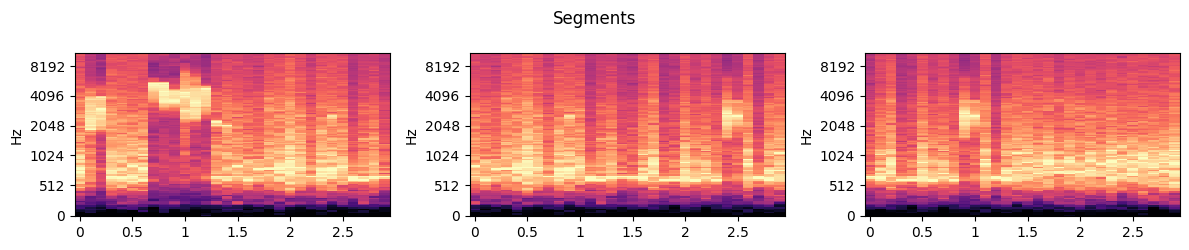

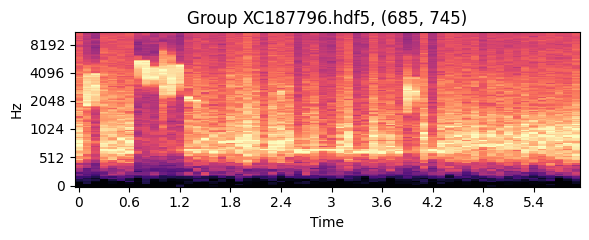

In [12]:
# /Users/jfgagnon/Projects/FeatheredFury/build/data_validation.hdf5
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC187796.hdf5 1365 0 (685, 715)
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC187796.hdf5 1365 1 (700, 730)
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC187796.hdf5 1365 2 (715, 745)

# /Users/jfgagnon/Projects/FeatheredFury/build/data_test.hdf5
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/thrnig1/XC287930.hdf5 1318 0 (344, 374)
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/thrnig1/XC287930.hdf5 1318 1 (359, 389)
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/thrnig1/XC287930.hdf5 1318 2 (374, 404)

# /Users/jfgagnon/Projects/FeatheredFury/build/data_train.hdf5
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC698511.hdf5 3727 0 (269, 299)
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC698511.hdf5 3727 1 (284, 314)
#      /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC698511.hdf5 3727 2 (299, 329)

plot_segments( dataset_validation.spectrogram_groups[1365] )
plot_group(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, "barswa/XC187796.hdf5"),
           685,
           745)

In [13]:
assert dataset_validation.spectrogram_groups.is_virtual

print(dataset_validation.spectrogram_groups[0, 0].shape, config.preprocess.clip_sampling_rate_hz)
print()
print( config.preprocess.group_frame_infos() )
print( config.preprocess.group_ms_infos() )
print()

(128, 30) 22050

(60, 30, 15)
(6000, 3000, 1500)

